In [5]:
# Montar Google Drive para acceder a las imágenes
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Importar librerías necesarias
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from collections import Counter

# Configurar visualizaciones
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [7]:
# Montar Google Drive primero
from google.colab import drive
drive.mount('/content/drive')

# Ruta correcta para ti
PATH_DATASET = '/content/drive/MyDrive/'

# Rutas de train y validation
train_path = os.path.join(PATH_DATASET, 'train')
val_path = os.path.join(PATH_DATASET, 'validation')

# Mapeo de emociones
emociones = {
    'angry': 'Enojo',
    'disgust': 'Disgusto',
    'fear': 'Miedo',
    'happy': 'Felicidad',
    'neutral': 'Neutral',
    'sad': 'Tristeza',
    'surprise': 'Sorpresa'
}

# Verificar que las rutas existen
print(f"¿Existe train?: {os.path.exists(train_path)}")
print(f"¿Existe validation?: {os.path.exists(val_path)}")
print("\nCarpetas dentro de train:")
if os.path.exists(train_path):
    print(os.listdir(train_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
¿Existe train?: True
¿Existe validation?: True

Carpetas dentro de train:
['angry', 'sad', 'surprise', 'fear', 'happy', 'disgust', 'neutral']


In [8]:
def contar_imagenes_por_emocion(ruta_base):
    """
    Cuenta cuántas imágenes hay en cada subcarpeta de emociones
    """
    conteo = {}
    for carpeta in os.listdir(ruta_base):
        ruta_carpeta = os.path.join(ruta_base, carpeta)
        if os.path.isdir(ruta_carpeta):
            num_imagenes = len([f for f in os.listdir(ruta_carpeta)
                                if f.endswith(('.png', '.jpg', '.jpeg'))])
            # Usar el nombre en español para mostrar
            nombre_emo = emociones.get(carpeta, carpeta)
            conteo[nombre_emo] = num_imagenes
    return conteo

# Contar imágenes en train y validation
conteo_train = contar_imagenes_por_emocion(train_path)
conteo_val = contar_imagenes_por_emocion(val_path)

print("=== DISTRIBUCIÓN EN TRAIN ===")
for emo, num in sorted(conteo_train.items(), key=lambda x: x[1], reverse=True):
    print(f"  {emo}: {num} imágenes")

print("\n=== DISTRIBUCIÓN EN VALIDATION ===")
for emo, num in sorted(conteo_val.items(), key=lambda x: x[1], reverse=True):
    print(f"  {emo}: {num} imágenes")

=== DISTRIBUCIÓN EN TRAIN ===
  Felicidad: 7164 imágenes
  Neutral: 4982 imágenes
  Tristeza: 4938 imágenes
  Miedo: 4103 imágenes
  Enojo: 3993 imágenes
  Sorpresa: 3205 imágenes
  Disgusto: 436 imágenes

=== DISTRIBUCIÓN EN VALIDATION ===
  Felicidad: 1825 imágenes
  Neutral: 1216 imágenes
  Tristeza: 1139 imágenes
  Miedo: 1018 imágenes
  Enojo: 960 imágenes
  Sorpresa: 797 imágenes
  Disgusto: 111 imágenes


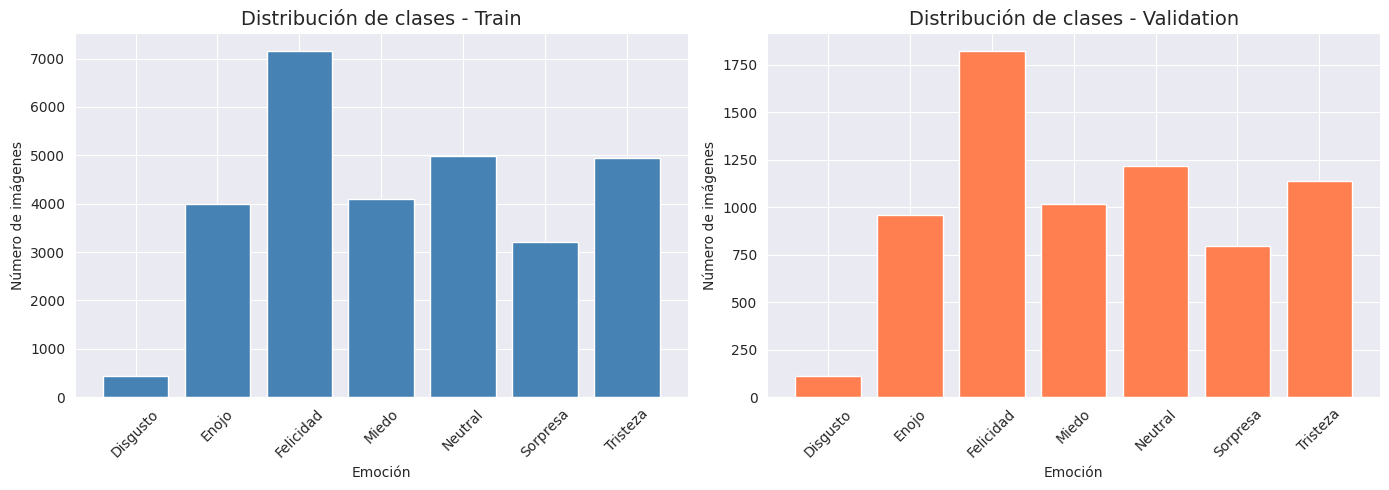


=== TABLA DE DISTRIBUCIÓN ===
  Emoción  Train  Validation
 Disgusto    436         111
    Enojo   3993         960
Felicidad   7164        1825
    Miedo   4103        1018
  Neutral   4982        1216
 Sorpresa   3205         797
 Tristeza   4938        1139


In [9]:
# Crear DataFrame para visualización
df_train = pd.DataFrame(list(conteo_train.items()), columns=['Emoción', 'Train'])
df_val = pd.DataFrame(list(conteo_val.items()), columns=['Emoción', 'Validation'])

# Unir ambos
df_dist = pd.merge(df_train, df_val, on='Emoción', how='outer').fillna(0)

# Gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
axes[0].bar(df_dist['Emoción'], df_dist['Train'], color='steelblue')
axes[0].set_title('Distribución de clases - Train', fontsize=14)
axes[0].set_xlabel('Emoción')
axes[0].set_ylabel('Número de imágenes')
axes[0].tick_params(axis='x', rotation=45)

# Validation
axes[1].bar(df_dist['Emoción'], df_dist['Validation'], color='coral')
axes[1].set_title('Distribución de clases - Validation', fontsize=14)
axes[1].set_xlabel('Emoción')
axes[1].set_ylabel('Número de imágenes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Mostrar también en tabla
print("\n=== TABLA DE DISTRIBUCIÓN ===")
print(df_dist.to_string(index=False))

In [10]:
def inspeccionar_muestras(ruta_base, num_muestras=2):
    """
    Toma muestras de cada emoción e inspecciona sus propiedades
    """
    resultados = []

    for carpeta in sorted(os.listdir(ruta_base)):
        ruta_carpeta = os.path.join(ruta_base, carpeta)
        if not os.path.isdir(ruta_carpeta):
            continue

        imagenes = [f for f in os.listdir(ruta_carpeta)
                    if f.endswith(('.png', '.jpg', '.jpeg'))]

        for img_nombre in imagenes[:num_muestras]:
            ruta_img = os.path.join(ruta_carpeta, img_nombre)
            img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                resultados.append({
                    'carpeta': carpeta,
                    'archivo': img_nombre,
                    'tamaño': img.shape,
                    'valor_min': img.min(),
                    'valor_max': img.max(),
                    'tipo_dato': img.dtype
                })
            else:
                resultados.append({
                    'carpeta': carpeta,
                    'archivo': img_nombre,
                    'tamaño': 'CORRUPTA',
                    'valor_min': None,
                    'valor_max': None,
                    'tipo_dato': None
                })

    return resultados

# Inspeccionar muestras de train
print("=== INSPECCIÓN DE MUESTRAS (TRAIN) ===\n")
resultados = inspeccionar_muestras(train_path, num_muestras=2)
df_inspeccion = pd.DataFrame(resultados)
print(df_inspeccion.to_string(index=False))

# Verificar si hay tamaños consistentes
tamanos = df_inspeccion[df_inspeccion['tamaño'] != 'CORRUPTA']['tamaño'].unique()
print(f"\n¿Todas las imágenes tienen el mismo tamaño?: {len(tamanos) == 1}")
if len(tamanos) == 1:
    print(f"  Tamaño estándar: {tamanos[0]}")
else:
    print(f"  Tamaños encontrados: {tamanos}")

# Verificar imágenes corruptas
corruptas = df_inspeccion[df_inspeccion['tamaño'] == 'CORRUPTA']
print(f"\n¿Imágenes corruptas en la muestra?: {len(corruptas) > 0}")

=== INSPECCIÓN DE MUESTRAS (TRAIN) ===

 carpeta   archivo   tamaño  valor_min  valor_max tipo_dato
   angry 35069.jpg (48, 48)          3        255     uint8
   angry 34589.jpg (48, 48)          0        255     uint8
 disgust  1073.jpg (48, 48)         15        183     uint8
 disgust 10137.jpg (48, 48)         22        222     uint8
    fear 34718.jpg (48, 48)          0        255     uint8
    fear 34641.jpg (48, 48)         13        255     uint8
   happy  5547.jpg (48, 48)          0        252     uint8
   happy  5309.jpg (48, 48)          0        255     uint8
 neutral 35456.jpg (48, 48)          0        255     uint8
 neutral 35430.jpg (48, 48)         15        255     uint8
     sad 35699.jpg (48, 48)          0        215     uint8
     sad 35714.jpg (48, 48)          6        146     uint8
surprise 32151.jpg (48, 48)          5        255     uint8
surprise 32004.jpg (48, 48)          0        250     uint8

¿Todas las imágenes tienen el mismo tamaño?: True
  Tamaño 

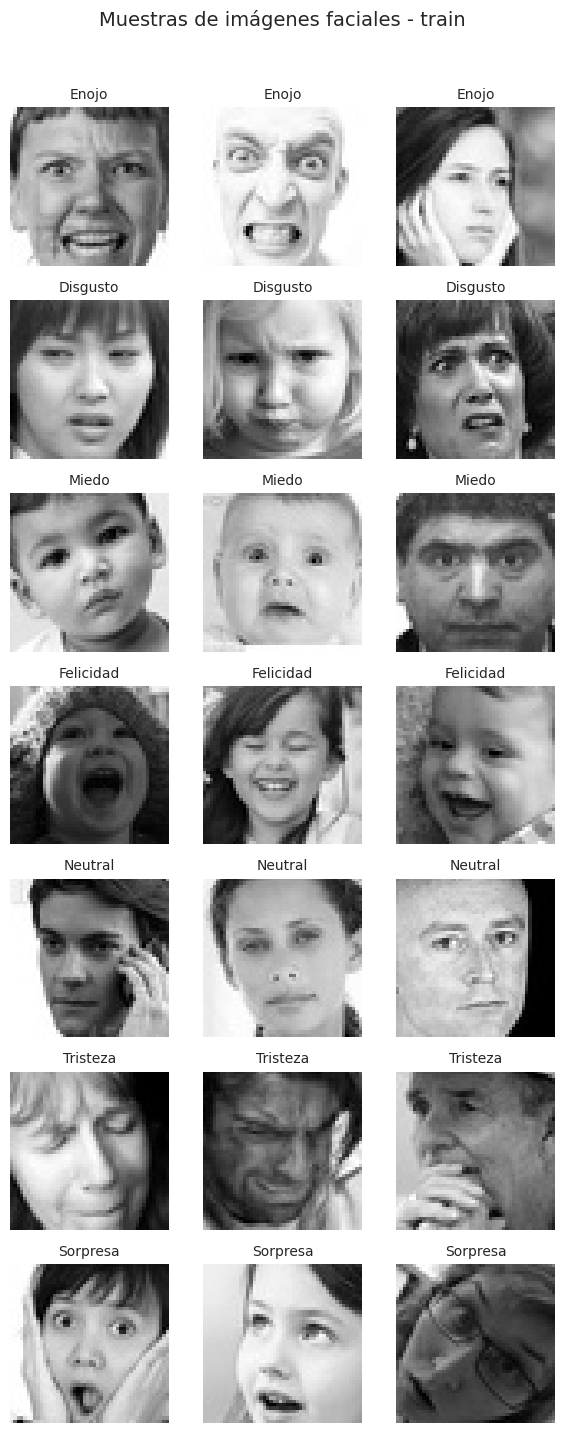

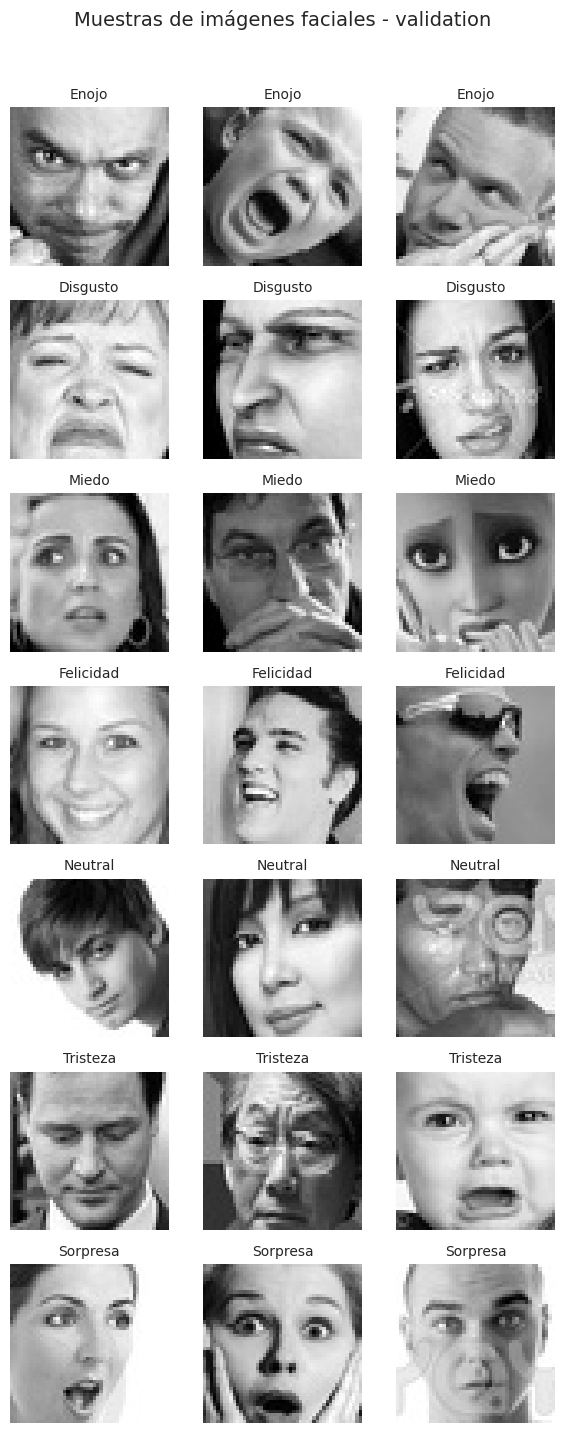

In [11]:
def mostrar_muestras_por_emocion(ruta_base, emociones_map, num_por_emocion=3):
    """
    Muestra una grilla de imágenes por cada emoción
    """
    emociones_carpetas = sorted([d for d in os.listdir(ruta_base)
                                  if os.path.isdir(os.path.join(ruta_base, d))])

    fig, axes = plt.subplots(len(emociones_carpetas), num_por_emocion,
                             figsize=(num_por_emocion * 2, len(emociones_carpetas) * 2))

    if len(emociones_carpetas) == 1:
        axes = axes.reshape(1, -1)

    for i, carpeta in enumerate(emociones_carpetas):
        ruta_carpeta = os.path.join(ruta_base, carpeta)
        imagenes = [f for f in os.listdir(ruta_carpeta)
                    if f.endswith(('.png', '.jpg', '.jpeg'))][:num_por_emocion]

        # Nombre bonito para el título
        nombre_mostrar = emociones_map.get(carpeta, carpeta)

        for j, img_name in enumerate(imagenes):
            ruta_img = os.path.join(ruta_carpeta, img_name)
            img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)

            ax = axes[i, j]
            if img is not None:
                ax.imshow(img, cmap='gray')
                ax.set_title(f"{nombre_mostrar}", fontsize=10)
            else:
                ax.text(0.5, 0.5, 'Error', ha='center', va='center')
            ax.axis('off')

    plt.suptitle(f'Muestras de imágenes faciales - {ruta_base.split("/")[-1]}',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Mostrar muestras de TRAIN
mostrar_muestras_por_emocion(train_path, emociones, num_por_emocion=3)

# Mostrar muestras de VALIDATION
mostrar_muestras_por_emocion(val_path, emociones, num_por_emocion=3)

In [12]:
print("=" * 60)
print("RESUMEN ESTADÍSTICO DEL EDA")
print("=" * 60)

# Totales
total_train = sum(conteo_train.values())
total_val = sum(conteo_val.values())

print(f"\n TOTAL DE IMÁGENES:")
print(f"   Train: {total_train} imágenes")
print(f"   Validation: {total_val} imágenes")
print(f"   Total general: {total_train + total_val} imágenes")

# Clase mayoritaria y minoritaria
clase_mayoritaria_train = max(conteo_train, key=conteo_train.get)
clase_minoritaria_train = min(conteo_train, key=conteo_train.get)

print(f"\n DISTRIBUCIÓN POR CLASE (TRAIN):")
print(f"   Clase con más imágenes: {clase_mayoritaria_train} ({conteo_train[clase_mayoritaria_train]} imágenes)")
print(f"   Clase con menos imágenes: {clase_minoritaria_train} ({conteo_train[clase_minoritaria_train]} imágenes)")

# Check de balanceo (ratio)
max_count = max(conteo_train.values())
min_count = min(conteo_train.values())
ratio = max_count / min_count
print(f"   Ratio desbalanceo (max/min): {ratio:.2f}")
if ratio > 1.5:
    print(f"    El dataset tiene desbalanceo significativo")
else:
    print(f"    El dataset está relativamente balanceado")

print(f"\n CALIDAD DE DATOS:")
print(f"   Tamaño de imágenes: 48x48 píxeles (según especificación del dataset)")
print(f"   Escala de grises: Valores 0-255 (uint8)")

RESUMEN ESTADÍSTICO DEL EDA

 TOTAL DE IMÁGENES:
   Train: 28821 imágenes
   Validation: 7066 imágenes
   Total general: 35887 imágenes

 DISTRIBUCIÓN POR CLASE (TRAIN):
   Clase con más imágenes: Felicidad (7164 imágenes)
   Clase con menos imágenes: Disgusto (436 imágenes)
   Ratio desbalanceo (max/min): 16.43
    El dataset tiene desbalanceo significativo

 CALIDAD DE DATOS:
   Tamaño de imágenes: 48x48 píxeles (según especificación del dataset)
   Escala de grises: Valores 0-255 (uint8)


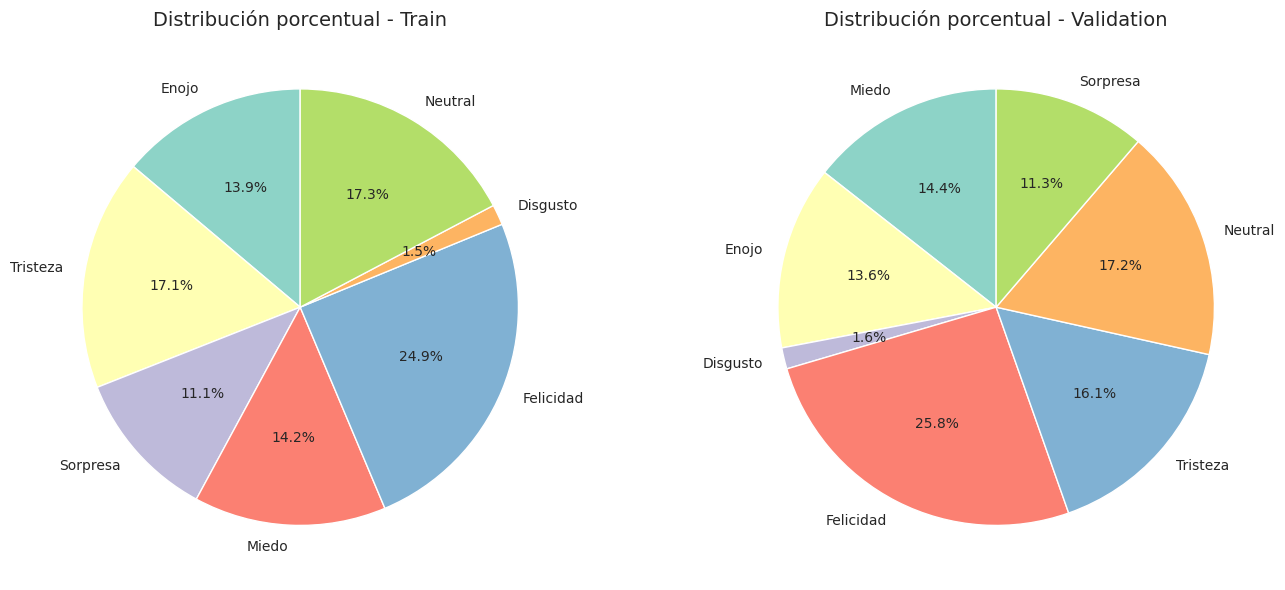

In [13]:
# Gráfico circular de distribución en train
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart - Train
ax[0].pie(conteo_train.values(), labels=conteo_train.keys(), autopct='%1.1f%%',
          startangle=90, colors=plt.cm.Set3(range(len(conteo_train))))
ax[0].set_title('Distribución porcentual - Train', fontsize=14)

# Pie chart - Validation
ax[1].pie(conteo_val.values(), labels=conteo_val.keys(), autopct='%1.1f%%',
          startangle=90, colors=plt.cm.Set3(range(len(conteo_val))))
ax[1].set_title('Distribución porcentual - Validation', fontsize=14)

plt.tight_layout()
plt.show()

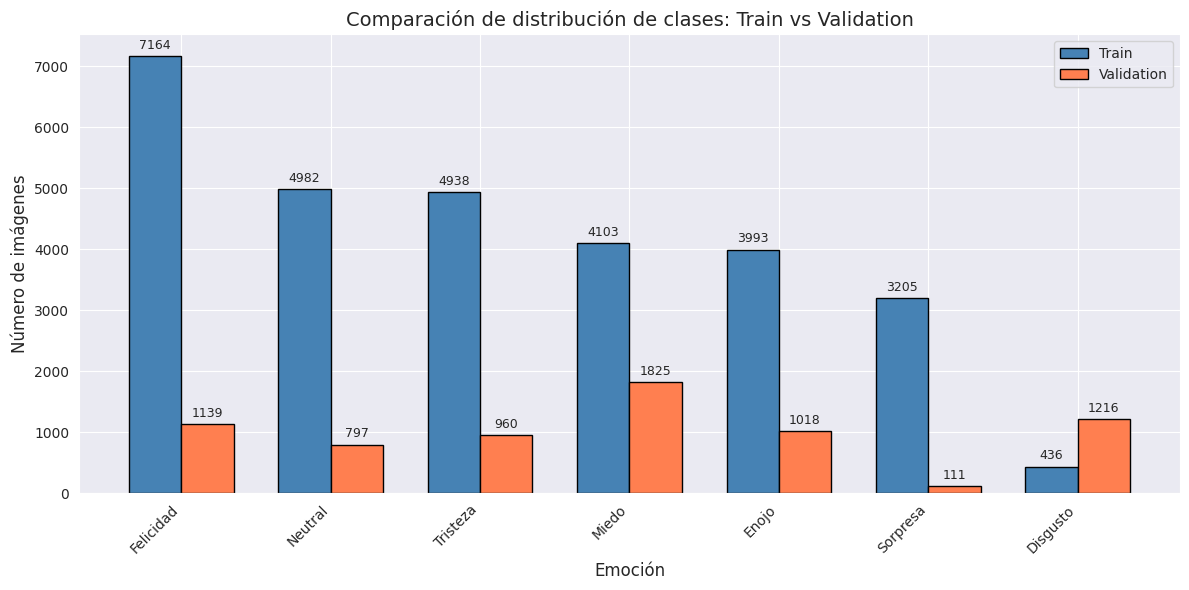


=== TABLA COMPARATIVA TRAIN vs VALIDATION ===
  Emoción  Train  Validation
Felicidad   7164        1139
  Neutral   4982         797
 Tristeza   4938         960
    Miedo   4103        1825
    Enojo   3993        1018
 Sorpresa   3205         111
 Disgusto    436        1216


In [14]:
# Crear DataFrame con los conteos de train y validation
df_compare = pd.DataFrame({
    'Emoción': list(conteo_train.keys()),
    'Train': list(conteo_train.values()),
    'Validation': list(conteo_val.values())
})

# Ordenar por cantidad de imágenes en train (de mayor a menor)
df_compare = df_compare.sort_values('Train', ascending=False)

# Configurar el gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Posiciones de las barras
x = range(len(df_compare['Emoción']))
width = 0.35  # ancho de cada barra

# Crear barras
bars1 = ax.bar([i - width/2 for i in x], df_compare['Train'],
               width, label='Train', color='steelblue', edgecolor='black')
bars2 = ax.bar([i + width/2 for i in x], df_compare['Validation'],
               width, label='Validation', color='coral', edgecolor='black')

# Etiquetas y título
ax.set_xlabel('Emoción', fontsize=12)
ax.set_ylabel('Número de imágenes', fontsize=12)
ax.set_title('Comparación de distribución de clases: Train vs Validation', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df_compare['Emoción'], rotation=45, ha='right')
ax.legend()

# Agregar valores encima de las barras
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Mostrar también la tabla comparativa
print("\n=== TABLA COMPARATIVA TRAIN vs VALIDATION ===")
print(df_compare.to_string(index=False))